# Customer Churn Prediction & Retention Intelligence System

## Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/IBM_Telco_customer_churn_IBM_dataset.csv")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
).fillna(0)

In [4]:
df["Churn Value"].value_counts(normalize=True) * 100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

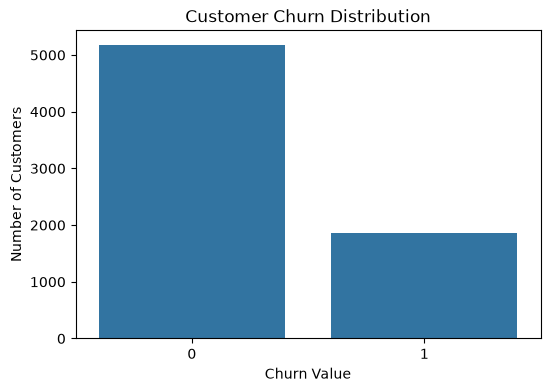

In [5]:
churn_counts = df["Churn Value"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values)
plt.xlabel("Churn Value")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

### Finding 
73.46% of customers did not churn, while 26.54% churned. Therefore, the dataset has a moderate class imbalance, which should be considered during model evaluation.

In [6]:
tenure_churn = (
    df.groupby(
        pd.cut(
            df["Tenure Months"],
            bins=[-1, 12, 24, 36, 48, 60, 72]
        )
    )["Churn Value"]
    .mean() * 100
)

tenure_churn

Tenure Months
(-1, 12]    47.438243
(12, 24]    28.710938
(24, 36]    21.634615
(36, 48]    19.028871
(48, 60]    14.423077
(60, 72]     6.609808
Name: Churn Value, dtype: float64

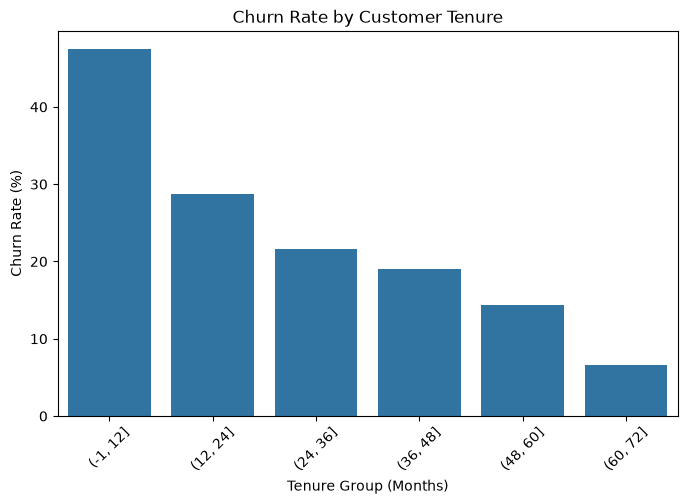

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=tenure_churn.index.astype(str),
    y=tenure_churn.values
)

plt.xlabel("Tenure Group (Months)")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Customer Tenure")
plt.xticks(rotation=45)
plt.show()

### Finding
* Customers with Tenure under 12 months are likely to churn
* ML implication: Tenure appears to be an informative feature for predicting churn, so the model should be able to use it to identify higher-risk newer customers.

Customers with month-to-month contracts may be more likely to churn than customers with one-year or two-year contracts.

In [8]:
contract_churn = (
    df.groupby("Contract")["Churn Value"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64

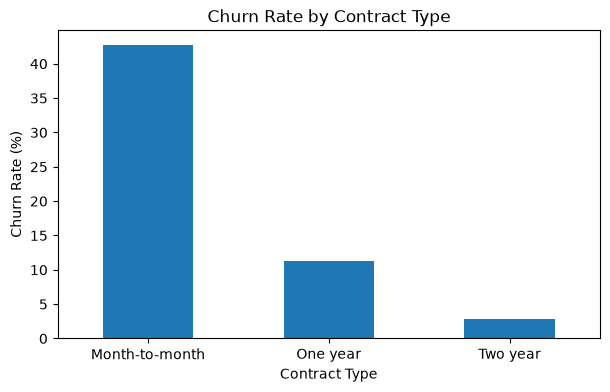

In [9]:
contract_churn.plot(kind="bar", figsize=(7, 4))

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=0)
plt.show()

Finding: Customers with month-to-month contracts have the highest churn rate.

ML implication: Contract type is likely an important feature for predicting customer churn.

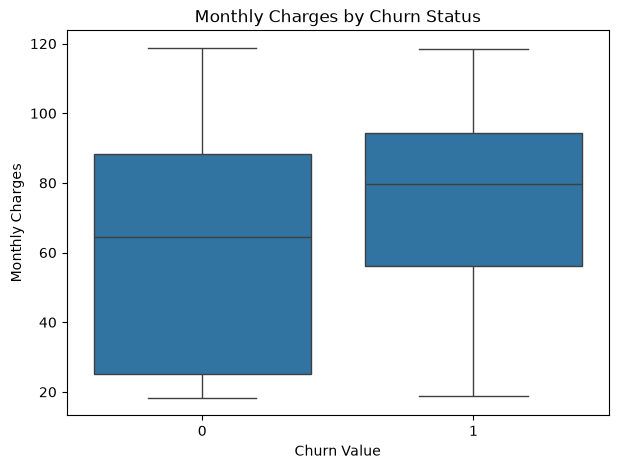

In [10]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Churn Value",
    y="Monthly Charges",
    data=df
)

plt.xlabel("Churn Value")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges by Churn Status")
plt.show()

Finding: Customers with lesser monthly charges are likely to not churn

In [11]:
df['Payment Method'].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [12]:
payment_churn = (
    df.groupby("Payment Method")["Churn Value"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

payment_churn

Payment Method
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn Value, dtype: float64

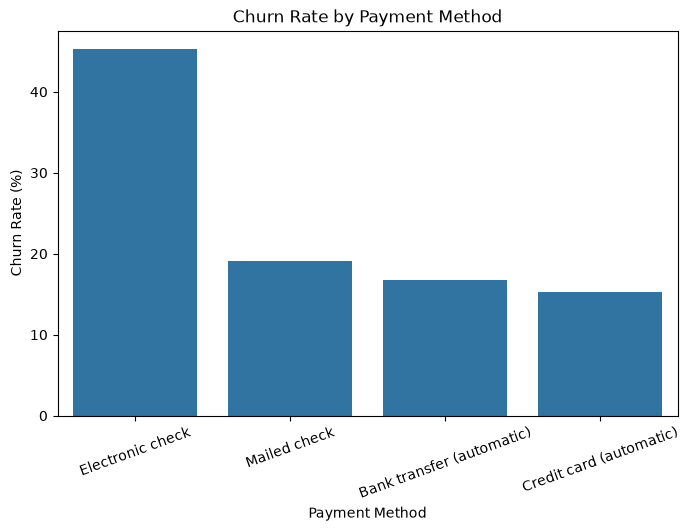

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=20)
plt.show()

Finding: Customers using Electronic Check have the highest churn rate.

ML implication: Payment Method may be a useful feature for predicting churn.

Business implication: The company should investigate why Electronic Check users churn more and consider encouraging automatic payment options.

In [14]:
df['Internet Service'].value_counts()

Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [15]:
internet_churn = (
    df.groupby("Internet Service")["Churn Value"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

internet_churn

Internet Service
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn Value, dtype: float64

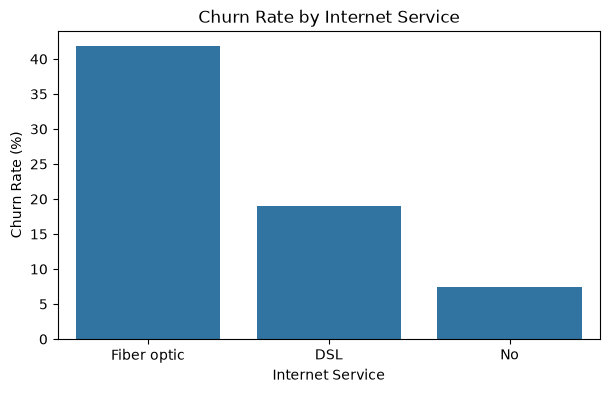

In [16]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Internet Service")
plt.show()

Finding: Fiber optic Customers have higher Churn rate.
ML implication: Internet Service might be a useful feature for prediction.
Bussiness implication: Company should investigate why Fiber optic users are churning more and what need to be done for this problem

In [17]:
df['Tech Support'].value_counts()

Tech Support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [18]:
tech_support_churn = (
    df.groupby("Tech Support")["Churn Value"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

tech_support_churn

Tech Support
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn Value, dtype: float64

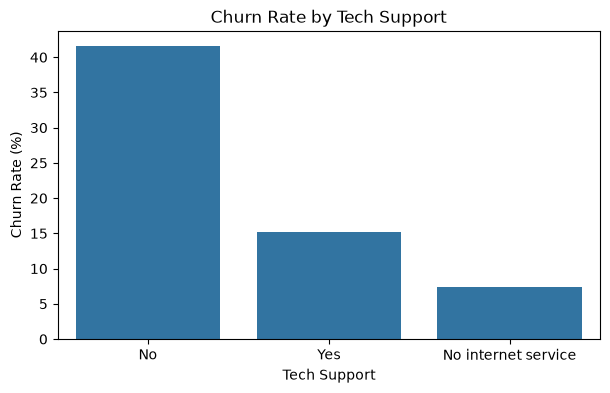

In [19]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=tech_support_churn.index,
    y=tech_support_churn.values
)

plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tech Support")
plt.show()

Finding: Customers without Tech Support have a higher churn rate.

In [21]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

In [22]:
contract_tenure_churn = (
    df.groupby(["Contract", "Tenure Group"])["Churn Value"]
      .mean()
      .mul(100)
      .unstack()
)

contract_tenure_churn

Tenure Group,0-12,13-24,25-48,49-72
Contract,,,,
Month-to-month,51.354062,37.720488,32.917706,26.023392
One year,10.483871,8.121827,10.617761,12.933754
Two year,0.000000,0.000000,2.189781,3.325416


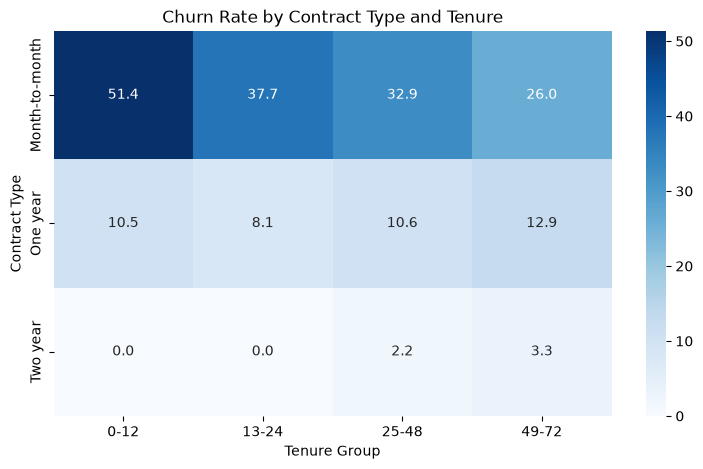

In [23]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    contract_tenure_churn,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.xlabel("Tenure Group")
plt.ylabel("Contract Type")
plt.title("Churn Rate by Contract Type and Tenure")
plt.show()

Finding: Customers with a month-to-month contract and 0–12 months of tenure have the highest churn rate.

ML implication: Contract and Tenure together may provide stronger predictive information than considering either feature alone.

Business implication: The company should focus retention efforts on new customers with month-to-month contracts.

In [24]:
senior_churn = (
    df.groupby("Senior Citizen")["Churn Value"]
      .mean()
      .mul(100)
)

senior_churn

Senior Citizen
No     23.606168
Yes    41.681261
Name: Churn Value, dtype: float64

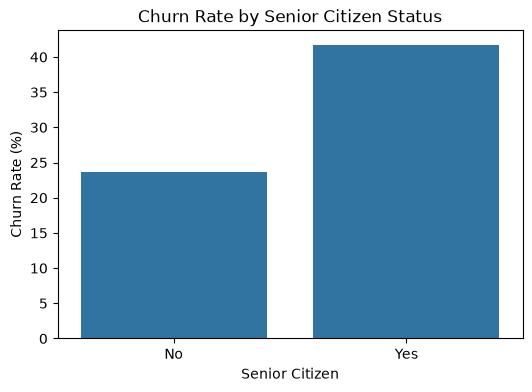

In [25]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=senior_churn.index,
    y=senior_churn.values
)

plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Senior Citizen Status")
plt.show()

Finding: Senior Citizen customers have a higher churn rate.

In [26]:
df['Paperless Billing'].value_counts()

Paperless Billing
Yes    4171
No     2872
Name: count, dtype: int64

In [27]:
paperless_churn = (
    df.groupby("Paperless Billing")["Churn Value"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

paperless_churn

Paperless Billing
Yes    33.565092
No     16.330084
Name: Churn Value, dtype: float64

Finding: Customers using Paperless Billing have a higher churn rate.

In [28]:
online_security_churn = (
    df.groupby("Online Security")["Churn Value"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

online_security_churn

Online Security
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn Value, dtype: float64

Finding: Customers without Online Security have a higher churn rate.

In [29]:
partner_churn = (
    df.groupby("Partner")["Churn Value"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

partner_churn

Partner
No     32.957979
Yes    19.664903
Name: Churn Value, dtype: float64

Finding: Customers without a partner have a higher churn rate.

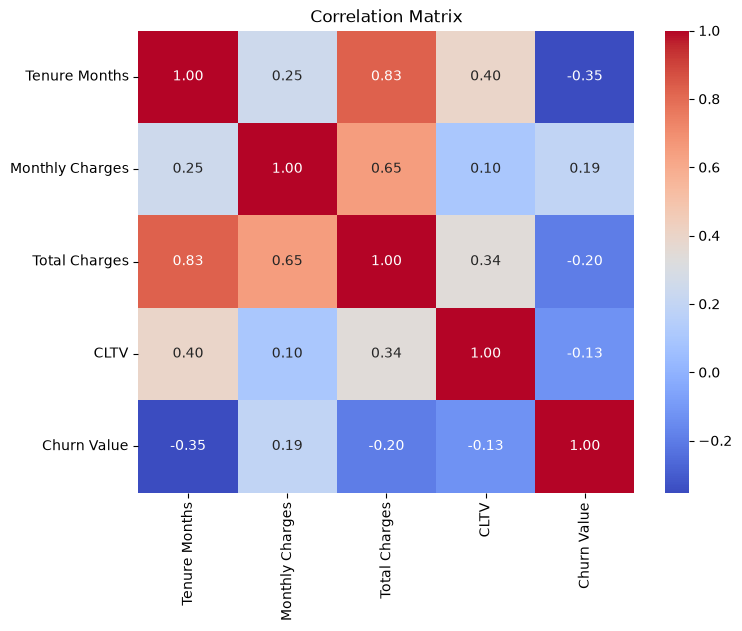

In [31]:
numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Value"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Findings: 
* Tenure months and Total Charges have strongest correlation with 0.83
* Churn Value and Tenure months have negative correlation of -0.35
* Churn Value and Total Charges have negative correlation of -0.20
* Total charges and monthly charges have strong coorelation of 0.65

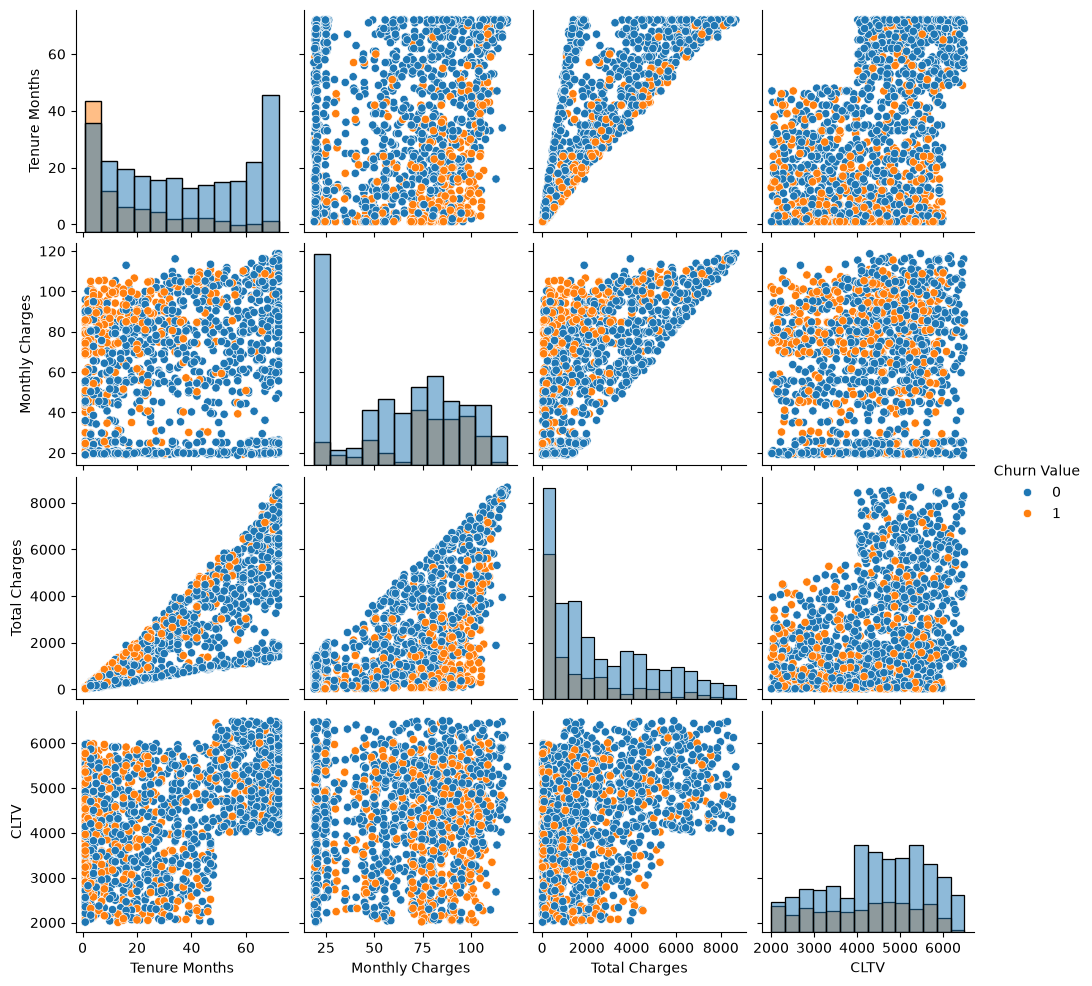

In [32]:
pairplot_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Value"
]

sample_df = df[pairplot_cols].sample(
    n=1500,
    random_state=42
)

sns.pairplot(
    sample_df,
    hue="Churn Value",
    diag_kind="hist"
)

plt.show()

Findings:
* As tenure increasing total charges are also increasing.
* Same with monthly charges and total charges.
* Total charges has a right skewed distribution.
* Monthly charges may have outliers.

# EDA Summary

## Key Business Findings

1. 26.5% of customers have churned, indicating moderate class imbalance.

2. Customers with shorter tenure show higher churn rates.

3. Month-to-month contract customers have the highest churn rate.

4. Customers with higher monthly charges show higher churn tendency.

5. Electronic Check users have the highest churn rate among payment methods.

6. Fiber Optic customers have the highest churn rate among Internet Service types.

7. Customers without Tech Support have a higher churn rate.

8. Customers without Online Security have a higher churn rate.

9. Senior Citizen customers have a higher churn rate.

10. Customers without a partner have a higher churn rate.

11. Month-to-month customers with low tenure represent a particularly high-risk segment.

## ML Implications

- Tenure, Contract, Monthly Charges and service-related features appear potentially useful for prediction.
- Class imbalance should be considered during model evaluation.
- Categorical variables will require encoding.
- Numerical variables will require appropriate preprocessing.
- Correlation and EDA relationships should not be interpreted as causation.